In [47]:
!pip install -q \
langchain==0.3.26 \
langchain-core==0.3.68 \
langchain-community==0.3.27 \
langchain-openai==0.3.27 \
langchain-huggingface==0.1.2 \
langgraph==0.5.3 \
faiss-cpu \
pandas

In [48]:
!pip list | grep -E "langchain|langgraph"

langchain                                0.3.26
langchain-community                      0.3.27
langchain-core                           0.3.68
langchain-huggingface                    0.1.2
langchain-openai                         0.3.27
langchain-protocol                       0.0.16
langchain-text-splitters                 0.3.8
langgraph                                0.5.3
langgraph-checkpoint                     2.1.2
langgraph-prebuilt                       0.5.2
langgraph-sdk                            0.1.74


In [49]:
import os
import pickle
import pandas as pd

from pathlib import Path
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph
from langgraph.graph import END
from langchain_huggingface import HuggingFaceEmbeddings

Project Files

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
PROJECT_DIR = Path("/content/drive/MyDrive/legal_ai")
VECTOR_DIR = PROJECT_DIR / "vectorstores"
METADATA_DIR = PROJECT_DIR / "metadata"
FAISS_DIR = VECTOR_DIR / "legal_faiss"

In [52]:
print("Project:", PROJECT_DIR)
print("Vector Store:", VECTOR_DIR)
print("Metadata:", METADATA_DIR)
print("FAISS:", FAISS_DIR)

Project: /content/drive/MyDrive/legal_ai
Vector Store: /content/drive/MyDrive/legal_ai/vectorstores
Metadata: /content/drive/MyDrive/legal_ai/metadata
FAISS: /content/drive/MyDrive/legal_ai/vectorstores/legal_faiss


In [53]:
#  Embeddings
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [54]:
faiss_db = FAISS.load_local(
    FAISS_DIR,
    embeddings,
    allow_dangerous_deserialization=True
)


In [55]:
print(type(faiss_db))

<class 'langchain_community.vectorstores.faiss.FAISS'>


In [56]:
!pip install rank-bm25

In [57]:
from rank_bm25 import BM25Okapi
with open("/content/drive/MyDrive/legal_ai/vectorstores/bm25.pkl",
    "rb"
) as f:

    bm25_retriever = pickle.load(f)

In [58]:
print(type(bm25_retriever))

<class 'langchain_community.retrievers.bm25.BM25Retriever'>


In [59]:
#  loading the metadata
metadata_df = pd.read_csv("/content/drive/MyDrive/legal_ai/metadata/contract_type_mapping.csv")

print(metadata_df.shape)

(510, 2)


In [60]:
# Loading the cleaned chunks
with open("/content/drive/MyDrive/legal_ai/vectorstores/chunks.pkl","rb") as f:

    chunks = pickle.load(f)

print("Chunks:",len(chunks))

Chunks: 37818


In [61]:
import os
os.environ["OPENAI_API_KEY"] ="bedrock-api-key-YmVkcm9jay5hbWF6b25hd3MuY29tLz9BY3Rpb249Q2FsbFdpdGhCZWFyZXJUb2tlbiZYLUFtei1BbGdvcml0aG09QVdTNC1ITUFDLVNIQTI1NiZYLUFtei1DcmVkZW50aWFsPUFTSUFYNjZWV1o0SzVFVTRYQ0tPJTJGMjAyNjA2MjIlMkZldS1ub3J0aC0xJTJGYmVkcm9jayUyRmF3czRfcmVxdWVzdCZYLUFtei1EYXRlPTIwMjYwNjIyVDEzMjkyM1omWC1BbXotRXhwaXJlcz00MzIwMCZYLUFtei1TZWN1cml0eS1Ub2tlbj1JUW9KYjNKcFoybHVYMlZqRUQwYUNtVjFMVzV2Y25Sb0xURWlSekJGQWlBM3UzVUZFMHQzazhla2lsMGRDWXA4ZVpsTkNuZiUyRk41Wlp6cGdGaCUyQk9kU0FJaEFMWHcxWkx6WVlIU3NWaGtIbGplRERKdDklMkZBckZNbDgwZXpJN0RUenVZdHVLcWtEQ0FjUUFCb01OVFEzTlRFNU5qUTNOVEE1SWd5Y0ZSMU0yMUFPQ0ZIbmdUMHFoZ1BTNWRSVUhGUWVRWGNFVUg0eHNsc1doeXYzTkJzaUpzWEh3TGZueXZaa1dEUmRraDFrMHI4aSUyQlNEWDAlMkZxTWhuMWtINTdzWUlpTGNjT0daTWdTMGZUTENzeWdnU2gxS1UxZ3dmZUxBajF5NVlZdm90JTJGeGc4NmdrWkRZY1EyekFGWFhGZWswNHF1OEd2aUtvR2xUdUluUFJnWXZIZiUyRjEwbmpvejd3Sjg4SmMzTmR6U3FwVDVlYnVSSVZJNnNCVlFJd2lldlRlRFVyckIlMkJ3bjk5JTJCRDNpYnJ5TGt3TlhpbnhEaXNONTloTUFoSHJnbHZTelUzc3VMdFdHNHVzZlhlbFlJc09OJTJCU1dDJTJGY3piTjdQM042YVZQZHl2Ymd2cHczd2VmRG9mYldINHV0YUV0NW5HeXlhVEtSVjkwZGVybnhSc2FxN2FiaXhEajJ1QmU1aEdwUVNoSE5xSWFkNnZGUlJYVnclMkZYJTJCYjNYbSUyQnFzWk9sTnA2SmVOd1VXUjYwMHBqOUdwZE5mSnlEa2xPbUhJQnA4ZGROWTIxcHdvbExIWWlNNjFzaUF5dEVXTzRiNkJjM2d3MXVBb3NpbEx4VGVVSDVCOUh2RldMJTJGM2tlOFFqZko3NmZ3Rkd0clFuRWVZRDlBRDRqdWt4Umh0SVlRak1ZWThnZ01IREd1TEJQNmMwM29OMXM4Z1RIQ2Njd3FmSGswUVk2M2dLM051NmlDczJXOUFEZmNxbVB2TVlabVhDSmpWUDM5MnFSNjFYTmVLJTJGSEVTVnNzQ1RjajQ2UmVxU0UxdGFBMGphWG95OW9obWh5M1h1RGpzUXJZMG5qdHBHMyUyQkpJNHZNTURzUTBXQ05oSXJuanM2ZXpPWmNxZ1MlMkJ3d0kyNlU3aFQ0OFVjeTBrS3htZFFZNll3TW12WFdmTkNVTnFNemF4S3FrbTF1Uklrd0tPWDBOUEhFbTlWYk83RlFHRzhEZDVMQ3czNGx3R1AlMkJWNUlOMnpRQzc1OW9ybCUyQiUyRjlsJTJGNUo2Qko2cjJ3UElnZ1pwQmgzOEJqRXozOU03cmtQZ1BlS2tIT2lJZDUlMkJOSGJyN1clMkYxOVg5ZGl3MEtTWFRncnMlMkZqSFpCMFltNVhIN1RrNUFXUHRDJTJCdyUyQk53U3Y5Tmd3NzJBa05MOTVTNjdmNmtXTkpHM1JOZEI0RzRCMk5NMkYyYTFBSVo0MFFEQ1UlMkJCejRWVWU1VVlaeHh2MVNudmJXbkxOck42TldzVWpUTm9lWlRXSlhOcDRFc0pSJTJGelNUZXdyWERLdm5lZFlEYVRJJTJCMzUyQk9pcFRrZTBKbnNSWEJRZUdzTVg2Y21UdDZMcSUyRlhJa2xXcmdhdyUzRCUzRCZYLUFtei1TaWduYXR1cmU9NzFkMjE1N2I3OThmNGZkYTk1OTgwMThiNjgxNjk1MmI3OTI0YTY2MDAwODMzNzY5ODdmOGVkZWExODRmYjZmMSZYLUFtei1TaWduZWRIZWFkZXJzPWhvc3QmVmVyc2lvbj0x"
os.environ["OPENAI_BASE_URL"]= "https://bedrock-mantle.eu-north-1.api.aws/v1"


In [62]:
llm = ChatOpenAI(
    model="openai.gpt-oss-120b",
    temperature=0
)

Reciprocal Rank Fusion

In [63]:
def reciprocal_rank_fusion(
    faiss_docs,
    bm25_docs,
    k=60
):

    scores = {}

    for rank, doc in enumerate(faiss_docs):

        key = doc.page_content

        scores[key] = scores.get(
            key,
            0
        ) + 1 / (rank + k)

    for rank, doc in enumerate(bm25_docs):

        key = doc.page_content

        scores[key] = scores.get(
            key,
            0
        ) + 1 / (rank + k)

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    doc_lookup = {}

    for doc in faiss_docs + bm25_docs:

        doc_lookup[
            doc.page_content
        ] = doc

    return [

        doc_lookup[text]

        for text, score in ranked
    ]

Hybrid Search

In [64]:
def hybrid_search(
    query,
    k=20
):

    faiss_results = faiss_db.similarity_search(
        query,
        k=k
    )

    bm25_results = bm25_retriever.invoke(
        query
    )[:k]

    fused_results = reciprocal_rank_fusion(
        faiss_results,
        bm25_results
    )

    return fused_results[:k]

LLM Reranking Section

In [65]:
ranking_prompt = ChatPromptTemplate.from_template(
"""
You are a legal retrieval expert.

QUESTION:
{question}

RETRIEVED CHUNKS:

{chunks}

Rank the 5 most relevant chunks for answering
the QUESTION.

Consider:

1. Direct relevance
2. Legal clause match
3. Completeness
4. Specificity
5. Whether the chunk helps answer the question

Return ONLY the chunk numbers in ranked order.

Example:

3,7,1,10,2

Do not explain.
Do not provide reasoning.
Do not write words.
Return only comma-separated chunk numbers
"""
)

In [66]:
rerank_chain = ranking_prompt | llm | StrOutputParser()

In [67]:
# Batch LLM Reranker

def batch_llm_rerank(
    question,
    docs,
    top_k=5
):

    formatted_chunks = ""

    for i, doc in enumerate(docs):

        formatted_chunks += f"""

CHUNK {i}

SOURCE:
{doc.metadata.get("source","Unknown")}

TEXT:
{doc.page_content[:800]}

----------------------------------------
"""

    response = rerank_chain.invoke(
        {
            "question": question,
            "chunks": formatted_chunks
        }
    )

    print(
        "RAW RANKING RESPONSE:"
    )

    print(response)

    try:

        ranked_indices = [

            int(x.strip())

            for x in response.split(",")
        ]

    except:

        ranked_indices = list(
            range(
                min(
                    top_k,
                    len(docs)
                )
            )
        )

    reranked_docs = []

    for idx in ranked_indices[:top_k]:

        if idx < len(docs):

            reranked_docs.append(
                docs[idx]
            )

    return reranked_docs

Advanced Retrieval

In [68]:
def advanced_retrieval(
    query,
    retrieve_k=20,
    final_k=5
):

    candidates = hybrid_search(
        query,
        k=retrieve_k
    )

    reranked = batch_llm_rerank(
        query,
        candidates,
        top_k=final_k
    )

    return reranked

In [69]:
#  Retrieval Testing
query = "confidentiality"

results = advanced_retrieval(
    query
)

for rank, doc in enumerate(
    results,
    start=1
):

    print("="*100)

    print(
        "RANK:",
        rank
    )

    print(
        "\nSOURCE:"
    )

    print(
        doc.metadata["source"]
    )

    print(
        "\nTYPE:"
    )

    print(
        doc.metadata.get(
            "contract_type",
            "Unknown"
        )
    )

    print(
        "\nTEXT:"
    )

    print(
        doc.page_content[:500]
    )

RAW RANKING RESPONSE:
10,16,14,12,6
RANK: 1

SOURCE:
Sonos, Inc. - Manufacturing Agreement .txt

TYPE:
Manufacturing Agreement

TEXT:
12.0 CONFIDENTIALITY.

12.1. Definition. "Confidential Information" shall mean any information that is transmitted or otherwise provided by or on behalf of the disclosing party, whether orally or in writing, to the receiving party during the course of its performance under this Agreement which is identified as "Confidential" at the time of disclosure or that should reasonably have been understood by the receiving party because of legends or other markings, the circumstances of disclosure or the 
RANK: 2

SOURCE:
LiquidmetalTechnologiesInc_20200205_8-K_EX-10.1_11968198_EX-10.1_Development Agreement.txt

TYPE:
Collaboration Agreement

TEXT:
9. CONFIDENTIALITY. 9.1 Certain Definitions. For purposes hereof, "Confidential Information" shall mean any and all commercial, technical, financial, proprietary, and other information relating to a Discloser, its Affil

Self Rag Setup


In [70]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

ambiguity_prompt = ChatPromptTemplate.from_template(
"""
You are a legal question evaluator.

Question:
{question}

Determine whether the question is specific enough
to be answered from a collection of contracts.

Examples:

Who is the CEO?
→ no

What is the stock price?
→ no

What is the governing law of the ADMA Manufacturing Agreement?
→ yes

What confidentiality obligations exist?
→ yes

Reply ONLY:

yes

or

no
"""
)

ambiguity_checker = ambiguity_prompt | llm | StrOutputParser()

def check_question_clarity(question):
    result = ambiguity_checker.invoke({"question": question})
    return result.lower().strip()

In [71]:
retrieval_grader_prompt = ChatPromptTemplate.from_template(
"""
You are a legal retrieval evaluator.

Question:
{question}

Retrieved Context:
{context}

Determine whether the retrieved context
contains sufficient evidence to answer
the question accurately.

Rules:

1. The answer must be directly supported.
2. The answer must not require guessing.
3. If the question is ambiguous, answer NO.
4. If multiple entities exist and the question
does not identify which one, answer NO.

Reply ONLY:

yes

or

no
"""
)

retrieval_grader = retrieval_grader_prompt | llm | StrOutputParser()

def grade_retrieval(question, docs):
    context = "\n\n".join(doc.page_content for doc in docs)
    result = retrieval_grader.invoke({
        "question": question,
        "context": context
    })
    return result.lower().strip()

In [72]:
retrieval_sufficiency_prompt = ChatPromptTemplate.from_template(
"""
You are a legal evidence evaluator.

Question:
{question}

Retrieved Context:
{context}

Decide whether the retrieved context contains sufficient evidence
to answer the question reliably.

Rules:
- If the answer is directly supported, answer YES
- If the evidence is weak, incomplete, or ambiguous, answer NO
- If there are multiple possible answers and the question does not specify which one, answer NO
- Do not guess

Reply ONLY with:
yes
or
no
"""
)

retrieval_sufficiency_chain = retrieval_sufficiency_prompt | llm | StrOutputParser()

def check_retrieval_sufficiency(question, docs):
    context = "\n\n".join(doc.page_content for doc in docs)
    result = retrieval_sufficiency_chain.invoke({
        "question": question,
        "context": context
    })
    return result.strip().lower()

In [73]:
answer_prompt = ChatPromptTemplate.from_template(
"""
You are a legal contract assistant.

Answer ONLY using the supplied context.

If the answer is not available,
say:

Information not found in retrieved contracts.

Question:
{question}

Context:
{context}
"""
)

answer_chain = answer_prompt | llm | StrOutputParser()

def generate_answer(question, docs):
    context = "\n\n".join(doc.page_content for doc in docs)
    return answer_chain.invoke({
        "question": question,
        "context": context
    })

    citations = build_source_citations(
        docs
    )

    final_answer = (
        answer
        + "\n\n"
        + citations
    )

    return final_answer

In [74]:
grounding_prompt = ChatPromptTemplate.from_template(
"""
You are a legal fact checker.

Retrieved Context:
{context}

Generated Answer:
{answer}

Is the answer fully supported
by the retrieved context?

Reply ONLY:

yes

or

no
"""
)

grounding_grader = grounding_prompt | llm | StrOutputParser()

def grade_grounding(answer, docs):
    context = "\n\n".join(doc.page_content for doc in docs)
    result = grounding_grader.invoke({
        "answer": answer,
        "context": context
    })
    return result.lower().strip()

In [75]:
answer_grader_prompt = ChatPromptTemplate.from_template(
"""
Question:
{question}

Generated Answer:
{answer}

Does the answer address
the user's question?

Reply ONLY: yes or no
"""
)

answer_grader = answer_grader_prompt | llm | StrOutputParser()

def grade_answer(question, answer):
    result = answer_grader.invoke({
        "question": question,
        "answer": answer
    })
    return result.lower().strip()

In [76]:
CLAUSE_KEYWORDS = [
    "governing law",
    "termination",
    "termination rights",
    "confidentiality",
    "indemnification",
    "force majeure",
    "intellectual property",
    "liability",
    "notice",
    "breach",
    "assignment",
    "arbitration",
    "payment terms",
    "liquidated damages",
    "warranty",
    "representation",
]

AMBIGUOUS_ENTITY_PATTERNS = [
    "who is the ceo",
    "what is the stock price",
    "who won the fifa world cup",
    "what is the market price",
    "who is the president",
]

def is_clause_question(question: str) -> bool:
    q = question.lower()
    return any(k in q for k in CLAUSE_KEYWORDS)

def is_entity_ambiguous(question: str) -> bool:
    q = question.lower()
    return any(p in q for p in AMBIGUOUS_ENTITY_PATTERNS)


question_router_prompt = ChatPromptTemplate.from_template(
"""
You are a legal question router.

Classify the question into exactly one of these labels:

- retrieve: the question should be answered using the contract corpus
- direct: the question can be answered without contract evidence
- clarify: the question is underspecified or ambiguous and needs more detail

Rules:
- Clause-style questions about legal provisions should be routed to retrieve, even if the exact agreement is not named.
- Example retrieve questions:
  - What confidentiality obligations exist?
  - What indemnification obligations exist?
  - What governing law clauses exist?
  - What termination rights exist?
  - What force majeure provisions exist?
- Ambiguous entity questions should be routed to clarify.
- Example clarify questions:
  - Who is the CEO?
  - What is the stock price?
  - Which company are you asking about?

Return ONLY one label:
retrieve
direct
clarify

Question:
{question}
"""
)

question_router_chain = question_router_prompt | llm | StrOutputParser()

def route_question(question: str) -> str:
    q = question.lower().strip()

    if is_clause_question(q):
        return "retrieve"

    if is_entity_ambiguous(q):
        return "clarify"

    result = question_router_chain.invoke({"question": question})
    result = result.strip().lower()

    if result not in {"retrieve", "direct", "clarify"}:
        return "clarify"

    return result

In [77]:
direct_answer_prompt = ChatPromptTemplate.from_template(
"""
You are a helpful assistant.

Answer the question directly and concisely.

Use general knowledge if the question is not about contracts.
If the question is ambiguous, say what detail is missing.
If you are not certain, say you do not know.

Question:
{question}
"""
)

direct_answer_chain = direct_answer_prompt | llm | StrOutputParser()

def generate_direct_answer(question):
    result = direct_answer_chain.invoke({"question": question})
    return result.strip()

In [78]:
query_rewrite_prompt = ChatPromptTemplate.from_template(
"""
You are a legal query rewriting system.

Original Question:
{question}

Retrieved Context:
{context}

Your job is to improve retrieval.

Rules:

1. Preserve the user's intent.
2. Never invent clause numbers.
3. Never invent jurisdictions.
4. Never invent parties.
5. Never assume facts not present.
6. Expand legal terminology.
7. Add likely contract language.
8. Make retrieval easier.
9. Return ONE rewritten query only.

Examples:

Question:
What happens if a party wants out?

Rewrite:
termination rights early termination termination clause cancellation rights agreement termination

Question:
Who owns the intellectual property?

Rewrite:
intellectual property ownership ownership clause proprietary rights ownership of inventions

Question:
What governing law provisions exist?

Rewrite:
governing law clause jurisdiction venue choice of law applicable law dispute jurisdiction

Question:
What force majeure provisions exist?

Rewrite:
force majeure clause acts of god notice requirements excused performance force majeure event

Question:
{question}

Rewrite:
"""
)

query_rewrite_chain = query_rewrite_prompt | llm | StrOutputParser()

def rewrite_question(question, docs):
    context = "\n\n".join(doc.page_content for doc in docs)
    result = query_rewrite_chain.invoke({
        "question": question,
        "context": context
    })
    return result.strip()

In [79]:
answer_revise_prompt = ChatPromptTemplate.from_template(
"""
You are a legal answer reviser.

Question:
{question}

Retrieved Context:
{context}

Previous Answer:
{answer}

The previous answer was not grounded or not useful.

Revise the answer so that it is fully supported by the context.
If no reliable answer can be made, say:
Information not found in retrieved contracts.

Return only the revised answer.
"""
)

answer_revise_chain = answer_revise_prompt | llm | StrOutputParser()

def revise_answer(question, docs, answer):
    context = "\n\n".join(doc.page_content for doc in docs)
    result = answer_revise_chain.invoke({
        "question": question,
        "context": context,
        "answer": answer
    })
    return result.strip()

In [80]:
intent_expansion_prompt = ChatPromptTemplate.from_template(
"""
You are an expert legal retrieval specialist.

Your job is to convert a user legal question into an optimized retrieval query
for searching legal contracts.

Rules:
1. Preserve the legal intent.
2. Expand legal terminology where useful.
3. Add synonyms commonly found in contracts.
4. Do NOT answer the question.
5. Do NOT ask for clarification.
6. Return ONLY a retrieval query.
7. Keep the query under 20 words.
8. Prefer contract language that would actually appear in legal clauses.

Examples:

Question:
What happens if a party wants out?

Query:
termination rights termination clause cancellation rights early termination agreement termination

Question:
What happens when a contract ends?

Query:
termination clause post termination obligations survival clause expiration agreement termination

Question:
Who owns the intellectual property?

Query:
intellectual property ownership ownership of IP proprietary rights ownership clause

Question:
What confidentiality obligations exist?

Query:
confidentiality clause confidential information non disclosure obligations confidentiality provisions

Question:
What indemnification obligations exist?

Query:
indemnification clause indemnify hold harmless liability obligations indemnity provisions

Question:
What governing law provisions exist?

Query:
governing law clause choice of law jurisdiction venue applicable law dispute jurisdiction

Question:
What force majeure provisions exist?

Query:
force majeure clause acts of god notice requirements excused performance force majeure event

Question:
What assignment rights exist?

Query:
assignment clause transfer rights delegation successor assignment consent transfer agreement

Question:
What dispute resolution provisions exist?

Query:
dispute resolution arbitration mediation governing law litigation venue dispute clause

Question:
{question}

Query:
"""
)

intent_expansion_chain =  intent_expansion_prompt   | llm   | StrOutputParser()

def expand_legal_intent(question):
    result = intent_expansion_chain.invoke({"question": question})
    result = result.strip()

    if not result or "please provide" in result.lower():
        return question

    return result

In [81]:
def self_rag(question, max_retries=3):

    original_question = question
    current_question = question

    print("=" * 80)
    print("ORIGINAL QUESTION")
    print(original_question)
    print("=" * 80)

    # -------------------------------------------------
    # ROUTER
    # -------------------------------------------------

    route = route_question(current_question)

    print(f"\nROUTE DECISION: {route}")

    if route == "clarify":

        return {
            "question": original_question,
            "final_question": current_question,
            "attempts_used": 0,
            "answer": "Question is ambiguous or underspecified. Please provide more specific details.",
            "sources": [],
            "status": "clarify_needed"
        }

    if route == "direct":

        answer = generate_direct_answer(current_question)

        return {
            "question": original_question,
            "final_question": current_question,
            "attempts_used": 0,
            "answer": answer,
            "sources": [],
            "status": "direct_answer"
        }

    # -------------------------------------------------
    # RETRIEVAL PATH
    # -------------------------------------------------

    attempt = 0
    docs = []
    answer = ""

    while attempt < max_retries:

        attempt += 1

        print("=" * 80)
        print(f"ATTEMPT {attempt}")
        print("=" * 80)

        print("\nCURRENT QUESTION:")
        print(current_question)

        # -------------------------------------------------
        # LEGAL INTENT EXPANSION
        # -------------------------------------------------

        retrieval_query = expand_legal_intent(
            current_question
        )

        # Safety fallback

        if retrieval_query is None:
            retrieval_query = current_question

        if len(retrieval_query.strip()) == 0:
            retrieval_query = current_question

        print("\nEXPANDED QUERY:")
        print(retrieval_query)

        # -------------------------------------------------
        # NOTEBOOK 06 HYBRID RETRIEVAL
        # -------------------------------------------------

        docs = advanced_retrieval(
            retrieval_query,
            retrieve_k=20,
            final_k=5
        )

        print(f"\nRetrieved Documents: {len(docs)}")

        # -------------------------------------------------
        # EVIDENCE CHECK
        # -------------------------------------------------

        sufficiency = check_retrieval_sufficiency(
            current_question,
            docs
        )

        print("Evidence Check:", sufficiency)

        if sufficiency != "yes":

            if attempt < max_retries:

                rewritten_query = rewrite_question(
                    current_question,
                    docs
                )

                print("\nREWRITTEN QUESTION")
                print(rewritten_query)

                current_question = rewritten_query

                continue

            return {
                "question": original_question,
                "final_question": current_question,
                "attempts_used": attempt,
                "answer": "Information not found in retrieved contracts.",
                "sources": [],
                "status": "retrieval_failed"
            }

        # -------------------------------------------------
        # ANSWER GENERATION
        # -------------------------------------------------

        answer = generate_answer(
            current_question,
            docs
        )

        print("\nGENERATED ANSWER")
        print(answer[:500])

        # -------------------------------------------------
        # GROUNDING CHECK
        # -------------------------------------------------

        grounding = grade_grounding(
            answer,
            docs
        )

        print("\nGrounding Check:", grounding)

        if grounding != "yes":

            if attempt < max_retries:

                answer = revise_answer(
                    current_question,
                    docs,
                    answer
                )

                print("\nREVISED ANSWER")
                print(answer[:500])

                grounding = grade_grounding(
                    answer,
                    docs
                )

                print(
                    "Grounding Check After Revision:",
                    grounding
                )

                if grounding == "yes":

                    relevance = grade_answer(
                        current_question,
                        answer
                    )

                    print(
                        "Relevance Check:",
                        relevance
                    )

                    if relevance == "yes":

                        return {
                            "question": original_question,
                            "final_question": current_question,
                            "attempts_used": attempt,
                            "answer": answer,
                            "sources": [
                                doc.metadata["source"]
                                for doc in docs
                            ],
                            "status": "success"
                        }

                continue

            return {
                "question": original_question,
                "final_question": current_question,
                "attempts_used": attempt,
                "answer": "Generated answer was not grounded in retrieved evidence.",
                "sources": [],
                "status": "grounding_failed"
            }

        # -------------------------------------------------
        # RELEVANCE CHECK
        # -------------------------------------------------

        relevance = grade_answer(
            current_question,
            answer
        )

        print("Relevance Check:", relevance)

        if relevance != "yes":

            if attempt < max_retries:

                rewritten_query = rewrite_question(
                    current_question,
                    docs
                )

                print("\nREWRITTEN QUESTION")
                print(rewritten_query)

                current_question = rewritten_query

                continue

            return {
                "question": original_question,
                "final_question": current_question,
                "attempts_used": attempt,
                "answer": "Generated answer did not answer the question.",
                "sources": [],
                "status": "answer_failed"
            }

        # -------------------------------------------------
        # SUCCESS
        # -------------------------------------------------

        return {
            "question": original_question,
            "final_question": current_question,
            "attempts_used": attempt,
            "answer": answer,
            "sources": [
                {
                    "source": doc.metadata.get(
                        "source",
                        "Unknown"
                    ),
                    "contract_type": doc.metadata.get(
                        "contract_type",
                        "Unknown"
                    )
                }
                for doc in docs
            ],
            "status": "success"
        }

    # -------------------------------------------------
    # MAX RETRIES EXHAUSTED
    # -------------------------------------------------

    return {
        "question": original_question,
        "final_question": current_question,
        "attempts_used": attempt,
        "answer": "Unable to generate a reliable answer after retries.",
        "sources": [],
        "status": "failed_after_retries"
    }

In [82]:
test_questions = [
    "Who is the CEO of the company?",
    "What is the stock price?",
    "Who won the FIFA World Cup?",
    "What confidentiality obligations exist?",
    "What indemnification obligations exist?",
    "What is the governing law of the agreement?",
    "What force majeure provisions exist?",
    "What termination rights exist?",
    "What is Neural Network?"
]

for q in test_questions:

    print("\n")
    print("=" * 100)
    print(q)

    result = self_rag(q)

    print("\nSTATUS:")
    print(result["status"])

    print("\nATTEMPTS:")
    print(result["attempts_used"])

    print("\nANSWER:")
    print(result["answer"])

    print("\nSOURCES:")

    if len(result["sources"]) == 0:

        print("No Sources")

    else:

        for idx, item in enumerate(
            result["sources"],
            start=1
        ):

            print(
                f"\n{idx}."
            )

            print(
                f"Source: {item['source']}"
            )

            print(
                f"Contract Type: {item['contract_type']}"
            )



Who is the CEO of the company?
ORIGINAL QUESTION
Who is the CEO of the company?

ROUTE DECISION: clarify

STATUS:
clarify_needed

ATTEMPTS:
0

ANSWER:
Question is ambiguous or underspecified. Please provide more specific details.

SOURCES:
No Sources


What is the stock price?
ORIGINAL QUESTION
What is the stock price?

ROUTE DECISION: clarify

STATUS:
clarify_needed

ATTEMPTS:
0

ANSWER:
Question is ambiguous or underspecified. Please provide more specific details.

SOURCES:
No Sources


Who won the FIFA World Cup?
ORIGINAL QUESTION
Who won the FIFA World Cup?

ROUTE DECISION: clarify

STATUS:
clarify_needed

ATTEMPTS:
0

ANSWER:
Question is ambiguous or underspecified. Please provide more specific details.

SOURCES:
No Sources


What confidentiality obligations exist?
ORIGINAL QUESTION
What confidentiality obligations exist?

ROUTE DECISION: retrieve
ATTEMPT 1

CURRENT QUESTION:
What confidentiality obligations exist?

EXPANDED QUERY:
confidentiality clause confidential information

In [83]:
test_queries = [
    "What happens if a party wants out?",
    "What happens when a contract ends?",
    "Who owns the intellectual property?",
    "What governing law provisions exist?",
    "What termination rights exist?"
]

for q in test_queries:
    print("\n")
    print("=" * 100)
    print(q)

    result = self_rag(q)

    print("\nSTATUS:")
    print(result["status"])

    print("\nATTEMPTS:")
    print(result["attempts_used"])

    print("\nANSWER:")
    print(result["answer"])

    print("\nSOURCES:")

    if len(result["sources"]) == 0:

        print("No Sources")

    else:

        for idx, item in enumerate(
            result["sources"],
            start=1
        ):

            print(
                f"\n{idx}."
            )

            print(
                f"Source: {item['source']}"
            )

            print(
                f"Contract Type: {item['contract_type']}"
            )



What happens if a party wants out?
ORIGINAL QUESTION
What happens if a party wants out?

ROUTE DECISION: retrieve
ATTEMPT 1

CURRENT QUESTION:
What happens if a party wants out?

EXPANDED QUERY:
termination rights termination clause cancellation rights early termination agreement termination
RAW RANKING RESPONSE:
0,10,8,15,18

Retrieved Documents: 5
Evidence Check: yes

GENERATED ANSWER
If a party wants to end the agreement, the contracts provide several ways to do so:

* **Termination for breach** – Either party may give written notice of a material breach. If the breaching party does not cure the breach within 30 days, the non‑breaching party may terminate the agreement immediately.

* **Termination for convenience** – A party may terminate the agreement without cause by giving advance written notice:
  * Party A may terminate at any time with 30 days’ notice (Intellectual Pr

Grounding Check: yes
Relevance Check: yes

STATUS:
success

ATTEMPTS:
1

ANSWER:
If a party wants to end t

In [84]:
test_queries2 = [
    "Who won nobel prize in physics last decade 2014-2023?",
    "What happens when a sun dies?"
]

for q in test_queries2:
    print("\n")
    print("=" * 100)
    print(q)

    result = self_rag(q)

    print("\nSTATUS:")
    print(result["status"])

    print("\nATTEMPTS:")
    print(result["attempts_used"])

    print("\nANSWER:")
    print(result["answer"])

    print("\nSOURCES:")

    if len(result["sources"]) == 0:

        print("No Sources")

    else:

        for idx, item in enumerate(
            result["sources"],
            start=1
        ):

            print(
                f"\n{idx}."
            )

            print(
                f"Source: {item['source']}"
            )

            print(
                f"Contract Type: {item['contract_type']}"
            )



Who won nobel prize in physics last decade 2014-2023?
ORIGINAL QUESTION
Who won nobel prize in physics last decade 2014-2023?

ROUTE DECISION: direct

STATUS:
direct_answer

ATTEMPTS:
0

ANSWER:
**Nobel Prize in Physics winners (2014‑2023)**  

- **2014:** Isamu Akasaki, Hiroshi Amano, Shuji Nakamura  
- **2015:** Takaaki Kajita, Arthur B. McDonald  
- **2016:** David J. Thouless, F. Duncan M. Haldane, J. Michael Kosterlitz  
- **2017:** Rainer Weiss, Barry C. Barish, Kip S. Thorne  
- **2018:** Arthur Ashkin, Gérard Mourou, Donna Strickland  
- **2019:** James Peebles, Michel Mayor, Didier Queloz  
- **2020:** Roger Penrose, Reinhard Genzel, Andrea Ghez  
- **2021:** Syukuro Manabe, Klaus Hasselmann, Giorgio Parisi  
- **2022:** Alain Aspect, John F. Clauser, Anton Zeilinger  
- **2023:** Pierre Agostini, Ferenc Krausz, Anne L’Huillier

SOURCES:
No Sources


What happens when a sun dies?
ORIGINAL QUESTION
What happens when a sun dies?

ROUTE DECISION: direct

STATUS:
direct_answer



In [86]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

class GraphState(TypedDict):
    question: str
    current_question: str
    route: str
    retrieval_query: str
    docs: list
    answer: str
    attempts_used: int
    max_retries: int
    evidence: str
    grounding: str
    relevance: str
    status: str
    sources: list

def route_question_node(state: GraphState):
    route = route_question(state["current_question"])
    return {"route": route}

def route_selector(state: GraphState):
    return state["route"]

def clarify_user_node(state: GraphState):
    return {
        "status": "clarify_needed",
        "answer": "Question is ambiguous or underspecified. Please provide more specific details.",
        "sources": []
    }

def direct_answer_node(state: GraphState):
    answer = generate_direct_answer(state["current_question"])
    return {
        "status": "direct_answer",
        "answer": answer,
        "sources": []
    }

def expand_intent_node(state: GraphState):
    retrieval_query = expand_legal_intent(state["current_question"])

    if not retrieval_query or not retrieval_query.strip():
        retrieval_query = state["current_question"]

    return {"retrieval_query": retrieval_query}

def retrieve_documents_node(state: GraphState):
    docs = advanced_retrieval(
        state["retrieval_query"],
        retrieve_k=20,
        final_k=5
    )
    return {
        "docs": docs,
        "attempts_used": state["attempts_used"] + 1
    }

def check_evidence_node(state: GraphState):
    evidence = check_retrieval_sufficiency(state["current_question"], state["docs"])
    return {"evidence": evidence}

def evidence_selector(state: GraphState):
    if state["evidence"] == "yes":
        return "generate_answer"

    if state["attempts_used"] < state["max_retries"]:
        return "rewrite_question"

    return "retrieval_failed"

def rewrite_question_node(state: GraphState):
    rewritten_query = rewrite_question(state["current_question"], state["docs"])

    if not rewritten_query or not rewritten_query.strip():
        rewritten_query = state["current_question"]

    return {"current_question": rewritten_query}

def generate_answer_node(state: GraphState):
    answer = generate_answer(state["current_question"], state["docs"])
    return {"answer": answer}

def check_grounding_node(state: GraphState):
    grounding = grade_grounding(state["answer"], state["docs"])
    return {"grounding": grounding}

def grounding_selector(state: GraphState):
    if state["grounding"] == "yes":
        return "check_relevance"

    if state["attempts_used"] < state["max_retries"]:
        return "revise_answer"

    return "grounding_failed"

def revise_answer_node(state: GraphState):
    revised = revise_answer(state["current_question"], state["docs"], state["answer"])
    return {"answer": revised}

def check_relevance_node(state: GraphState):
    relevance = grade_answer(state["current_question"], state["answer"])
    return {"relevance": relevance}

def relevance_selector(state: GraphState):
    if state["relevance"] == "yes":
        return "success"

    if state["attempts_used"] < state["max_retries"]:
        return "rewrite_question"

    return "answer_failed"

def success_node(state: GraphState):
    return {
        "status": "success",
        "sources": [
            {
                "source": doc.metadata.get("source", "Unknown"),
                "contract_type": doc.metadata.get("contract_type", "Unknown")
            }
            for doc in state["docs"]
        ]
    }

def retrieval_failed_node(state: GraphState):
    return {
        "status": "retrieval_failed",
        "answer": "Information not found in retrieved contracts.",
        "sources": []
    }

def grounding_failed_node(state: GraphState):
    return {
        "status": "grounding_failed",
        "answer": "Generated answer was not grounded in retrieved evidence.",
        "sources": []
    }

def answer_failed_node(state: GraphState):
    return {
        "status": "answer_failed",
        "answer": "Generated answer did not answer the question.",
        "sources": []
    }

builder = StateGraph(GraphState)

builder.add_node("route_question", route_question_node)
builder.add_node("clarify_user", clarify_user_node)
builder.add_node("direct_answer", direct_answer_node)
builder.add_node("expand_intent", expand_intent_node)
builder.add_node("retrieve_documents", retrieve_documents_node)
builder.add_node("check_evidence", check_evidence_node)
builder.add_node("rewrite_question", rewrite_question_node)
builder.add_node("generate_answer", generate_answer_node)
builder.add_node("check_grounding", check_grounding_node)
builder.add_node("revise_answer", revise_answer_node)
builder.add_node("check_relevance", check_relevance_node)
builder.add_node("success", success_node)
builder.add_node("retrieval_failed", retrieval_failed_node)
builder.add_node("grounding_failed", grounding_failed_node)
builder.add_node("answer_failed", answer_failed_node)

builder.set_entry_point("route_question")

builder.add_conditional_edges(
    "route_question",
    route_selector,
    {
        "clarify": "clarify_user",
        "direct": "direct_answer",
        "retrieve": "expand_intent"
    }
)

builder.add_edge("expand_intent", "retrieve_documents")
builder.add_edge("retrieve_documents", "check_evidence")

builder.add_conditional_edges(
    "check_evidence",
    evidence_selector,
    {
        "generate_answer": "generate_answer",
        "rewrite_question": "rewrite_question",
        "retrieval_failed": "retrieval_failed"
    }
)

builder.add_edge("rewrite_question", "expand_intent")
builder.add_edge("generate_answer", "check_grounding")

builder.add_conditional_edges(
    "check_grounding",
    grounding_selector,
    {
        "check_relevance": "check_relevance",
        "revise_answer": "revise_answer",
        "grounding_failed": "grounding_failed"
    }
)

builder.add_edge("revise_answer", "check_grounding")

builder.add_conditional_edges(
    "check_relevance",
    relevance_selector,
    {
        "success": "success",
        "rewrite_question": "rewrite_question",
        "answer_failed": "answer_failed"
    }
)

builder.add_edge("clarify_user", END)
builder.add_edge("direct_answer", END)
builder.add_edge("success", END)
builder.add_edge("retrieval_failed", END)
builder.add_edge("grounding_failed", END)
builder.add_edge("answer_failed", END)

graph = builder.compile()

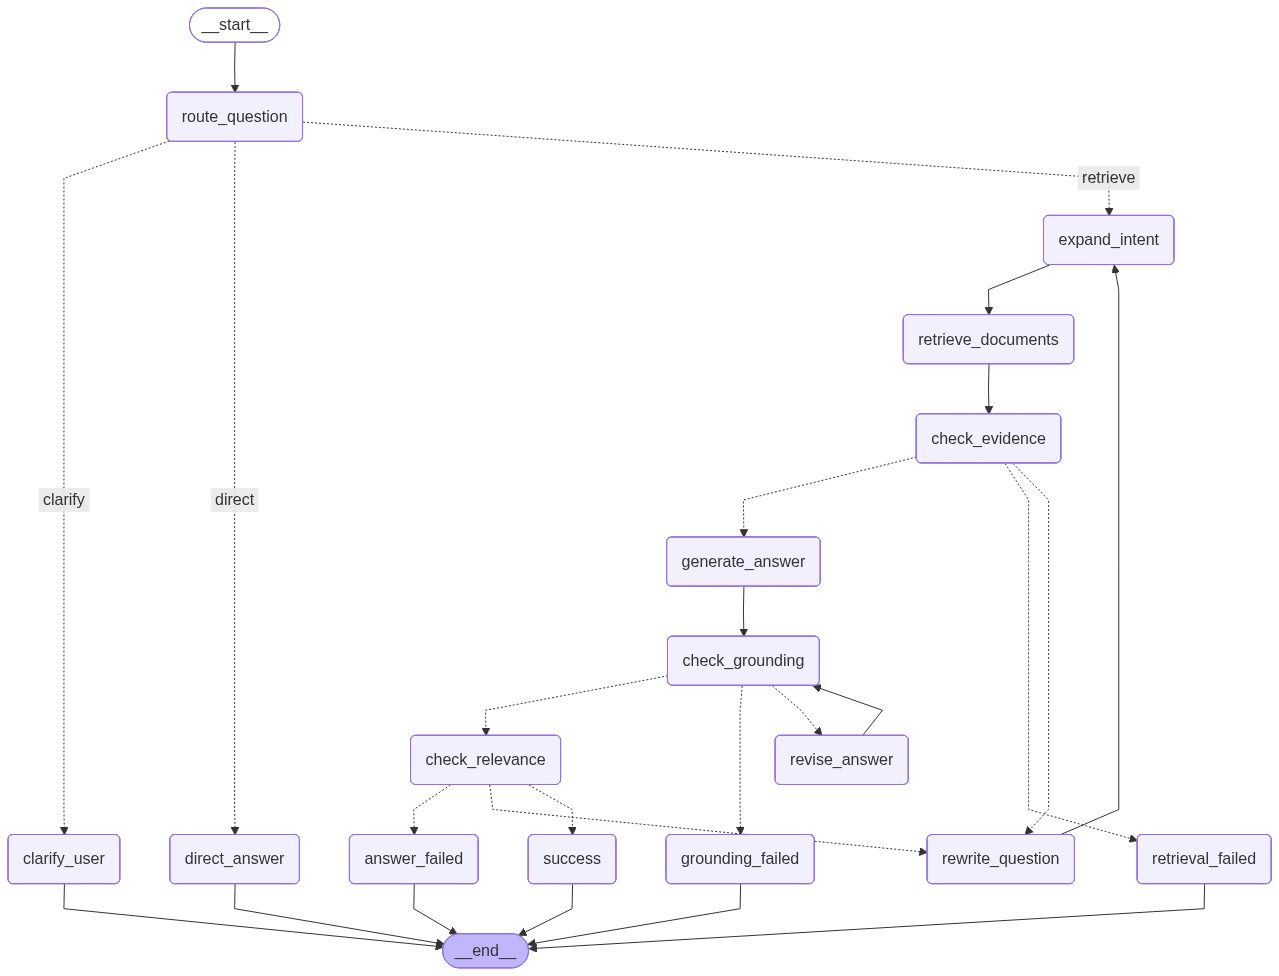

In [88]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [87]:
result = graph.invoke(
    {
        "question": "What governing law provisions exist?",
        "current_question": "What governing law provisions exist?",
        "route": "",
        "retrieval_query": "",
        "docs": [],
        "answer": "",
        "attempts_used": 0,
        "max_retries": 3,
        "evidence": "",
        "grounding": "",
        "relevance": "",
        "status": "",
        "sources": []
    }
)

RAW RANKING RESPONSE:
0,3,4,1,2
